# MC Dropout with Bensemble

In this notebook, we will demonstrate how to use **bensemble** to perform Bayesian approximation using **Monte-Carlo dropout**.

We will fit a regression model on synthetic data and visualize the uncertainty estimation capabilities of the library.

In [7]:
# 🛠 Setup: Import library from parent folder
# This allows you to run the notebook without installing the package via pip
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Bensemble imports
from bensemble.utils import predict_with_uncertainty
from bensemble.diversity.dropout import MCDropoutEnsembler

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Generate Synthetic Data

We create a simple 1D regression task: $y = x^3 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 1)$.
Notice that we train on range `[-2, 2]`, but later we will test on `[-4, 4]` to see how the model behaves on out-of-distribution data.

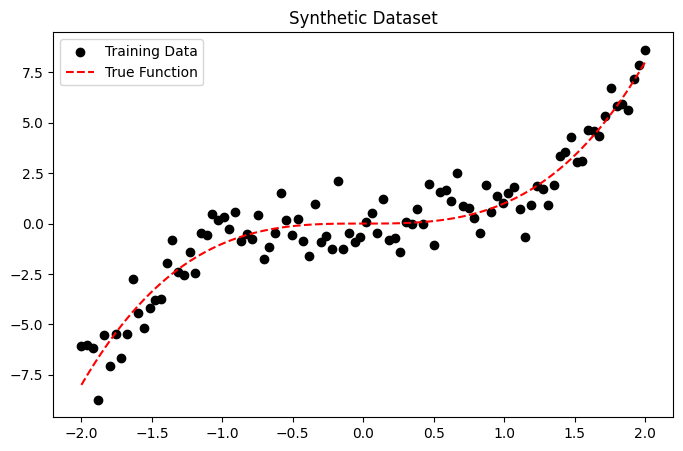

In [8]:
def true_function(x):
    return x**3

# Generate Training Data 
x_train = torch.linspace(-2, 2, 100).reshape(-1, 1)
y_train = true_function(x_train) + torch.randn_like(x_train) # Add noise

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, c='k', label='Training Data')
plt.plot(x_train, true_function(x_train), 'r--', label='True Function')
plt.legend()
plt.title("Synthetic Dataset")
plt.show()

## 2. Define the Bayesian Model

We use `BayesianLinear` layers instead of standard `nn.Linear`. These layers use the **Local Reparameterization Trick** to sample weights during training.

In [11]:
model = nn.Sequential(
    nn.Linear(1, 100),
    nn.Dropout(p=0.3),
    nn.ReLU(),
    nn.Linear(100, 1),
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): Dropout(p=0.3, inplace=False)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=1, bias=True)
)


## 3. Setup Objectives

We use **GaussianLikelihood** to model the noise in the data  and **VariationalLoss** to minimize the ELBO.

> **Tip:** Change `alpha=0.5` in `VariationalLoss` to use **Rényi Divergence** instead of ELBO.

In [14]:
loss_fn = nn.MSELoss()

# Optimize both model parameters and likelihood noise
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## 4. Training Loop

Standard PyTorch training loop. We just need to calculate KL divergence using `get_total_kl`.

In [17]:
epochs = 1000
model.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    
    preds = model(x_train)
    
    loss = loss_fn(preds, y_train)
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train loss: {loss.item():.4f}")

Epoch 100/1000 | Train loss: 0.9478
Epoch 200/1000 | Train loss: 1.1146
Epoch 300/1000 | Train loss: 0.8829
Epoch 400/1000 | Train loss: 0.8857
Epoch 500/1000 | Train loss: 0.8384
Epoch 600/1000 | Train loss: 0.9224
Epoch 700/1000 | Train loss: 0.9591
Epoch 800/1000 | Train loss: 1.0886
Epoch 900/1000 | Train loss: 0.9198
Epoch 1000/1000 | Train loss: 0.9314


## 5. Ensemble Creation

Now let's finally create a Bayesian predictor out of the model using MCDropoutEnsembler:

In [24]:
ensembler = MCDropoutEnsembler(model)

predictor = ensembler.build_ensemble(num_samples=100)

## 6. Visualization & Uncertainty

Now we predict on a wider range `[-4, 4]` using Monte Carlo sampling via `predict_with_uncertainty`.

Notice how the uncertainty (blue area) expands where we have no training data.

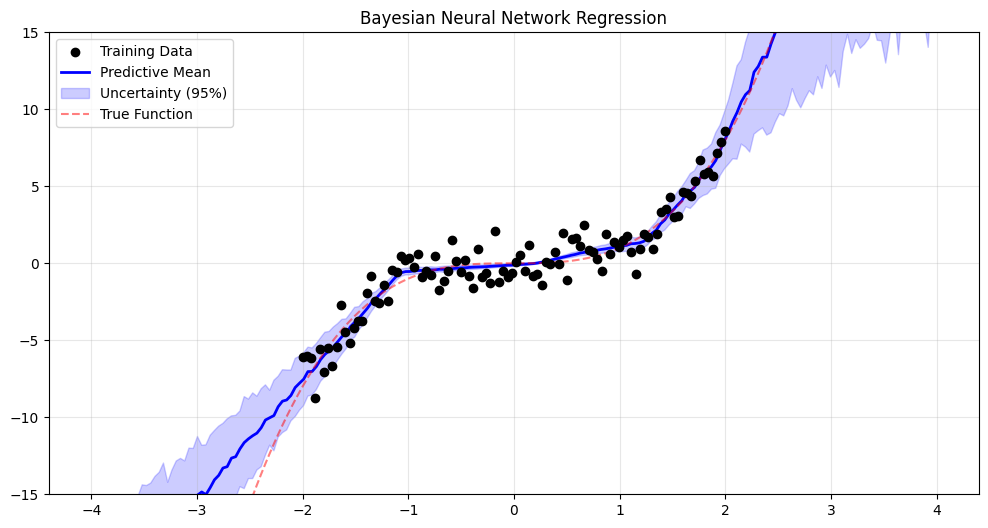

In [25]:
# Test on a wider range to see out-of-distribution behavior
x_test = torch.linspace(-4, 4, 200).reshape(-1, 1)

# Get model predictions and uncertainty (mean & std from 100 MC samples)
preds = predictor.predict_members(x_test)
mean, std = preds.mean(dim=0), preds.std(dim=0, unbiased=True)

# Prepare for plotting
x = x_test.flatten().numpy()
y_mean = mean.flatten().numpy()
y_std = std.flatten().numpy()

# --- PLOTTING ---
plt.figure(figsize=(12, 6))

# Training Data
plt.scatter(x_train, y_train, c='black', zorder=5, label='Training Data')

# Mean Prediction
plt.plot(x, y_mean, c='blue', linewidth=2, label='Predictive Mean')

# Uncertainty Bands (2 Sigma = 95% confidence)
plt.fill_between(x, y_mean - 2*y_std, y_mean + 2*y_std, 
                 color='blue', alpha=0.2, label='Uncertainty (95%)')

# True Function
plt.plot(x, true_function(torch.tensor(x)), 'r--', alpha=0.5, label='True Function')

plt.ylim(-15, 15)
plt.title("Bayesian Neural Network Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()